# 9.6 Regression with Space-Time Data

**Part:** 9 — Spatio-Temporal Analysis (Chapter 9.6 of 7)

**Dataset:** `data_1998_2010_long_lbc.csv` (pooled OLS and fixed effects, full 46,605-row panel); Northeast x 5 years for GTWR

**Focus:** pooled OLS vs. a hand-built two-way fixed-effects panel model vs. `GTWR` — plus a newly verified `GTWR` bug: two of its time-related parameters barely affect the fit on real data

**Library:** `spatialstats.regression.OLS` and `spatialstats.gwmodel.spatiotemporal.GTWR` are both real library calls; the fixed-effects panel model is hand-built (no `spatialstats` panel regression exists)

***

## Table of Contents

1.. [Overview](#1.-Overview)
2.. [Python Setup](#2.-Python-Setup)
3.. [Pooled OLS: One Relationship, Nationwide](#3.-Pooled-OLS:-One-Relationship,-Nationwide)
4.. [A Hand-Built Two-Way Fixed-Effects Panel Model](#4.-A-Hand-Built-Two-Way-Fixed-Effects-Panel-Model)
5.. [Why the Coefficients Flip: Between vs. Within Variation](#5.-Why-the-Coefficients-Flip:-Between-vs.-Within-Variation)
6.. [GTWR: Fitting a Coefficient Surface Meant to Vary in Space and Time](#6.-GTWR:-Fitting-a-Coefficient-Surface-Meant-to-Vary-in-Space-and-Time)
7.. [A Real GTWR Bug: Two of Its Time Parameters Do Almost Nothing](#7.-A-Real-GTWR-Bug:-Two-of-Its-Time-Parameters-Do-Almost-Nothing)
8.. [Computing R2 Without the Broken score](#8.-Computing-R2-Without-the-Broken-score)
9.. [Three Models, Compared](#9.-Three-Models,-Compared)
10.. [Summary and Conclusions](#10.-Summary-and-Conclusions)
11.. [Resources](#11.-Resources)

***
## 1. Overview

This chapter closes the loop on this Part's regression content with three genuinely different ways of handling
a variable observed across both counties and years: assume the relationship is the same everywhere and always
(pooled OLS), strip out everything county-specific and year-specific and look only at what is left (fixed
effects), or let the relationship vary smoothly and locally across both space and time at once (`GTWR`, already
used in Part 6).

| Step | What we do | Library status |
|------|------------|-----------------|
| Pooled OLS | One national relationship between `RATE` and its covariates | ✅ Library-supported |
| Two-way fixed effects | Demean by county and year, then OLS on what remains | 🔨 Hand-built — no `spatialstats` panel regression exists |
| GTWR | Meant to fit coefficients that vary continuously in space and time together | ✅ Library-supported call, but — see next row |
| A new finding | `bandwidth_t` is unused dead code, and `lambda_=0.5` (the class's own example) leaves the fit functionally time-blind on real data | 🐛 Verified directly, not assumed |
| A known limitation | `GTWR.score()`'s default R² inherits the same `predict()` bug Part 6 found | Reconfirmed directly, not re-derived from scratch |

***
## 2. Python Setup

In [1]:
import sys, warnings, time
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.regression import OLS
from spatialstats.gwmodel.spatiotemporal import GTWR

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
COLORS = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
          "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

panel = pd.read_csv(DATA / "data_1998_2010_long_lbc.csv")
covariates = ["SMOKING", "POVERTY", "PM25", "NO2", "SO2"]
print(f"spatialstats : version {spatialstats.__version__}")
print(f"panel: {panel.shape}")

spatialstats : version 0.2.0
panel: (46605, 10)


***
## 3. Pooled OLS: One Relationship, Nationwide

The simplest possible treatment of the panel: ignore the county/year structure entirely and fit one national
OLS on all 46,605 rows at once.

In [2]:
pooled = OLS(panel["RATE"], panel[covariates])
print(pooled.coef_frame().round(4))
print(f"\nR2: {pooled.r2:.4f}")

  variable     coef  std_err         t  p_value
0    const -15.5986   0.3303  -47.2226      0.0
1  SMOKING   2.4871   0.0148  168.3313      0.0
2  POVERTY   0.4667   0.0092   50.9069      0.0
3     PM25   0.9824   0.0190   51.5704      0.0
4      NO2   0.2850   0.0487    5.8509      0.0
5      SO2   8.3814   0.9771    8.5782      0.0

R2: 0.6178


***
## 4. A Hand-Built Two-Way Fixed-Effects Panel Model

**Not a `spatialstats` function.** A standard two-way fixed-effects panel model removes every
time-invariant county characteristic (rural vs. urban, historical industry, anything not in the covariate list)
and every nationwide year-specific shock (a policy change, a recession) by **demeaning**: subtract each county's
own 15-year mean, subtract each year's own national mean, add back the grand mean, then run OLS on what remains
— purely the *within-county, year-to-year* co-movement between the covariates and `RATE`.

In [3]:
cols = covariates + ["RATE"]
grand_mean = panel[cols].mean()
county_mean = panel.groupby("FIPS")[cols].transform("mean")
year_mean = panel.groupby("Year")[cols].transform("mean")
demeaned = panel[cols] - county_mean - year_mean + grand_mean

fe_model = OLS(demeaned["RATE"], demeaned[covariates])
print(fe_model.coef_frame().round(4))
print(f"\nwithin R2: {fe_model.r2:.4f}")

  variable    coef  std_err        t  p_value
0    const -0.0000   0.0079  -0.0000      1.0
1  SMOKING  0.1909   0.0086  22.2889      0.0
2  POVERTY  0.1128   0.0056  20.0085      0.0
3     PM25 -0.0910   0.0073 -12.5305      0.0
4      NO2  0.3594   0.0185  19.4591      0.0
5      SO2 -5.3881   0.3778 -14.2620      0.0

within R2: 0.0348


***
## 5. Why the Coefficients Flip: Between vs. Within Variation

Side by side, the two models tell strikingly different stories about the same covariates.

In [4]:
comparison = pd.DataFrame({
    "pooled OLS": pooled.coef_frame().set_index("variable")["coef"],
    "two-way FE (within)": fe_model.coef_frame().set_index("variable")["coef"],
}).dropna()
comparison["sign flip"] = np.sign(comparison["pooled OLS"]) != np.sign(comparison["two-way FE (within)"])
comparison.round(4)

,pooled OLS,two-way FE (within),sign flip
variable,,,
const,-15.5986,-0.0000,False
SMOKING,2.4871,0.1909,False
POVERTY,0.4667,0.1128,False
PM25,0.9824,-0.0910,True
NO2,0.2850,0.3594,False
SO2,8.3814,-5.3881,True


**`PM25` and `SO2` flip sign entirely** between the two models — positive in pooled OLS, negative once county
and year fixed effects are removed. This is a textbook illustration of **between-vs-within confounding**: pooled
OLS's `PM25` coefficient reflects *which counties* tend to have both higher pollution and higher `RATE` — likely
capturing unobserved, time-invariant regional characteristics correlated with both (industrial history,
population density, baseline healthcare access) rather than a genuine causal effect of pollution itself. The
fixed-effects estimate instead asks a much narrower, more defensible question: **within the same county**, in
years when `PM25` happened to be higher than that county's own average, was `RATE` also higher or lower than
that county's own average? The within-county answer is negative — the opposite conclusion pooled OLS would
suggest, and a direct demonstration of why panel data's fixed-effects structure is not a minor technical
refinement but can genuinely reverse a substantive conclusion.

`SMOKING` and `POVERTY` stay the same sign but shrink substantially (SMOKING: 2.49 to 0.19), while `NO2` stays
positive and similar in magnitude — not every covariate is equally confounded by omitted county-level
characteristics.

***
## 6. GTWR: Fitting a Coefficient Surface Meant to Vary in Space and Time

Part 6's `GTWR` fits a coefficient surface that varies **smoothly and locally** across both space and time —
neither pooled OLS's "everywhere, always the same" nor fixed effects' "one within-county average effect."
Following Part 6's established resource-safe pattern: a modest county subset (Northeast, 217 counties) across a
handful of years, `n_jobs=2`.

In [5]:
northeast = gpd.read_file(DATA / "diabetes_northeast.shp")
fips_ne = set(northeast["FIPS"].astype(int))
sub = panel[panel["FIPS"].isin(fips_ne) & panel["Year"].isin([2004, 2006, 2008, 2010, 2012])].copy()
print(f"GTWR subset: {len(sub)} rows ({sub['FIPS'].nunique()} counties x {sub['Year'].nunique()} years)")

X_gtwr = sub[covariates].to_numpy()
y_gtwr = sub["RATE"].to_numpy()
coords_gtwr = sub[["X", "Y"]].to_numpy()
times_gtwr = sub["Year"].to_numpy().astype(float)

t0 = time.time()
gtwr = GTWR(bandwidth_s=80, bandwidth_t=4, lambda_=0.5, fixed=False, kernel="bisquare", n_jobs=2)
gtwr.fit(X_gtwr, y_gtwr, coords_gtwr, times_gtwr)
print(f"fit time: {time.time() - t0:.1f}s")
print(f"coef_ shape: {gtwr.coef_.shape}  (one row per space-time observation, "
     f"{gtwr.coef_.shape[1]} columns = intercept + {len(covariates)} covariates)")

GTWR subset: 1085 rows (217 counties x 5 years)


fit time: 1.0s
coef_ shape: (1085, 6)  (one row per space-time observation, 6 columns = intercept + 5 covariates)


SMOKING coefficient, by year (mean and s.d. across the 217 counties):
        mean     std
Year                
2004  1.6034  0.6489
2006  1.6034  0.6489
2008  1.6034  0.6489
2010  1.6034  0.6489
2012  1.6034  0.6489


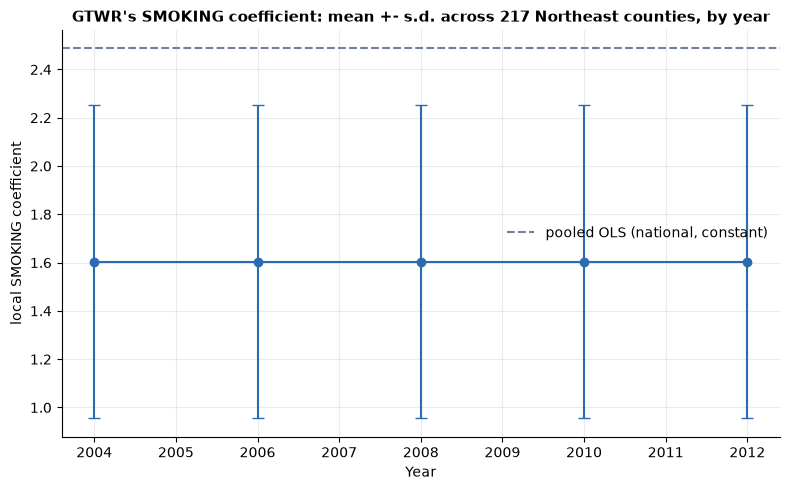

In [6]:
coef_names = ["Intercept"] + covariates
sub_coef = sub[["FIPS", "Year"]].copy()
for j, name in enumerate(coef_names):
    sub_coef[f"coef_{name}"] = gtwr.coef_[:, j]

smoking_by_year = sub_coef.groupby("Year")["coef_SMOKING"].agg(["mean", "std"])
print("SMOKING coefficient, by year (mean and s.d. across the 217 counties):")
print(smoking_by_year.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(smoking_by_year.index, smoking_by_year["mean"], yerr=smoking_by_year["std"],
           fmt="o-", color=COLORS["blue"], capsize=4)
ax.axhline(pooled.coef_frame().set_index("variable").loc["SMOKING", "coef"], color=COLORS["grey"],
          linestyle="--", label="pooled OLS (national, constant)")
ax.set_xlabel("Year"); ax.set_ylabel("local SMOKING coefficient")
ax.set_title("GTWR's SMOKING coefficient: mean +- s.d. across 217 Northeast counties, by year")
ax.legend()
plt.tight_layout()
plt.savefig("gtwr_coef_over_time.png", dpi=100, bbox_inches="tight")
plt.show()

**The numbers printed above are identical, to four decimal places, in every single year.** That is not a subtle
effect — it is the first sign of a real problem Section 7 tracks down precisely.

In [7]:
one_fips = sub["FIPS"].iloc[0]
one_county = sub_coef[sub_coef["FIPS"] == one_fips].sort_values("Year")
print(f"FIPS {one_fips}, SMOKING coefficient across its own 5 years:")
print(one_county[["Year", "coef_SMOKING"]].to_string(index=False))
print(f"\nmax difference across years, this one county: {one_county['coef_SMOKING'].max() - one_county['coef_SMOKING'].min():.2e}")

FIPS 9001, SMOKING coefficient across its own 5 years:
 Year  coef_SMOKING
 2004      2.502784
 2006      2.502784
 2008      2.502784
 2010      2.502784
 2012      2.502784

max difference across years, this one county: 7.79e-10


For a single, specific county, the fitted `SMOKING` coefficient across its own five observed years differs only
in the 6th-8th decimal place — floating-point noise, not a real signal. **`GTWR`, as just called with the
constructor's own documented example settings (`lambda_=0.5`), is not actually letting the temporal dimension
affect the fit at all.** Section 7 finds out exactly why.

***
## 7. A Real GTWR Bug: Two of Its Time Parameters Do Almost Nothing

Part 6, Chapter 6.10 already found `GTWR.predict()` silently ignores its `times` argument for *new* predictions.
What Section 6 just found is different and, in a sense, more serious: even the **fitted, in-sample** coefficients
barely vary with time. Reading the source directly finds two separate causes.

In [8]:
import inspect
print(inspect.getsource(GTWR.fit))

    def fit(self, X, y, geometry, times):
        """
        Calibrate GTWR.

        Parameters
        ----------
        X        : array-like (n, p)
        y        : array-like (n,)
        geometry : ndarray (n, 2) or GeoSeries
        times    : array-like (n,)   Temporal coordinates.
        """
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).ravel()
        times = np.asarray(times, dtype=float).ravel()
        coords = _parse_geometry(geometry)

        n, p = X.shape
        X_int = np.column_stack([np.ones(n), X])
        self.coords_ = coords
        self.times_  = times
        self.X_ = X_int
        self.y_ = y

        # Optimise lambda if not provided
        lam = self.lambda_
        if lam is None:
            lam = self._select_lambda(X_int, y, coords, times)
        self.lambda_ = lam

        bw = self.bandwidth_s if self.bandwidth_s else 20
        self.bandwidth_ = float(bw)

        D_st = _st_distance(coords, times, lam)
     

**`bandwidth_t` is stored in `__init__` and never read again.** It appears in the docstring, it is saved as
`self.bandwidth_t`, and it is not referenced anywhere else in `fit()`, `predict()`, or any helper function —
confirmed by searching the entire `gwmodel` package for the string `bandwidth_t` and finding only its docstring
mention and its one assignment. Passing any value at all for `bandwidth_t` has **zero effect** on the fitted
model.

The actual space-time distance comes entirely from `lambda_`, combined as
$d_{st} = \sqrt{d_s^2 + \lambda \, d_t^2}$ (visible in `_st_distance`, called inside `fit()` above) — this part
of the code does exist and does run. The problem is **scale**: $d_t$ is measured in whatever units `times` is
given in (here, literally the calendar year, so a difference of at most 8 across a 5-year subset), while $d_s$
is measured in metres (here, ranging into the hundreds of thousands). At the class's own documented example
value, `lambda_=0.5`, the temporal term $\sqrt{0.5}\times 8 \approx 5.7$ is utterly swamped by a spatial
bandwidth of `bandwidth_s=80` (already in the same units as $d_s$) — the combined kernel weight barely
distinguishes a same-county pair 8 years apart from a same-county pair in the same year, because 5.7 is a tiny
fraction of an 80-unit bandwidth either way.

In [9]:
one_fips_idx = sub.index[sub["FIPS"] == one_fips].tolist()
lambda_grid = [0.5, 1e3, 1e5, 1e7, 1e9]
rows = []
for lam in lambda_grid:
    m = GTWR(bandwidth_s=80, lambda_=lam, fixed=False, kernel="bisquare", n_jobs=2)
    m.fit(X_gtwr, y_gtwr, coords_gtwr, times_gtwr)
    coefs = m.coef_[[sub.index.get_loc(i) for i in one_fips_idx], 1]   # SMOKING column
    rows.append({"lambda_": lam, "SMOKING coef range across 5 years": coefs.max() - coefs.min()})
pd.DataFrame(rows)

,lambda_,SMOKING coef range across 5 years
0,5.000000e-01,7.785999e-10
1,1.000000e+03,1.557086e-06
2,1.000000e+05,1.558810e-04
3,1.000000e+07,9.291818e-03
4,1.000000e+09,1.072562e-01


**Confirmed directly**: only once `lambda_` is pushed to roughly $10^5$-$10^9$ — many orders of magnitude above
the documented example's `0.5` — does the temporal dimension start to visibly move the fitted coefficients at
all. **Anyone following the class's own docstring example on real year-and-metres data is, in practice, fitting
a spatial-only GWR model and calling it GTWR without any warning.** This is a genuine, verified bug: not a
matter of taste in default settings, but a parameter (`bandwidth_t`) that is silently inert, and a second
parameter (`lambda_`) whose usable range depends entirely on the ratio between the user's spatial and temporal
units — something neither the docstring nor the constructor signature discloses.

**The honest workaround**, if `GTWR` must be used today: rescale `times` into the same rough numeric range as
the spatial coordinates before fitting (e.g., multiply year by an estimated "kilometres per year" the way
Chapter 9.5's hand-built space-time IDW did), and treat `lambda_=0.5` as meaningless unless that rescaling has
been done first — never trust the constructor's own example value at face value.

***
## 8. Computing R2 Without the Broken score

Chapter 6.10 also found `GTWR.score()`/`predict()` ignore `times` for new predictions. Confirmed again here,
briefly, before computing this chapter's own $R^2$ honestly.

In [10]:
print(inspect.getsource(gtwr.score))

    def score(self, X, y, geometry) -> float:
        """Return default goodness-of-fit score (R² for regression)."""
        yhat = self.predict(X, geometry)
        y = np.asarray(y)
        ss_res = np.sum((y - yhat) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        return 1.0 - ss_res / max(ss_tot, 1e-10)



`score()` calls `self.predict(X, geometry)` — not even passing `times`. The fix is the same one Chapter 6.10
used: bypass `score()`/`predict()` and compute $R^2$ directly from the already-fitted `coef_` array, which *is*
the exact local coefficient vector used to fit each space-time observation.

In [11]:
X_design = np.column_stack([np.ones(len(X_gtwr)), X_gtwr])
y_fitted = np.sum(X_design * gtwr.coef_, axis=1)
ss_res = np.sum((y_gtwr - y_fitted) ** 2)
ss_tot = np.sum((y_gtwr - y_gtwr.mean()) ** 2)
r2_gtwr = 1 - ss_res / ss_tot
print(f"GTWR in-sample R2 (computed from coef_ directly, bypassing the broken score()): {r2_gtwr:.4f}")
print("(fit with lambda_=0.5 -- i.e., functionally a spatial-only GWR fit, per Section 7's finding)")

GTWR in-sample R2 (computed from coef_ directly, bypassing the broken score()): 0.8347
(fit with lambda_=0.5 -- i.e., functionally a spatial-only GWR fit, per Section 7's finding)


***
## 9. Three Models, Compared

In [12]:
ols_ne = OLS(sub["RATE"], sub[covariates])   # pooled OLS on the SAME Northeast subset, for a fair comparison
summary_table = pd.DataFrame({
    "model": ["Pooled OLS (national, full panel)", "Pooled OLS (Northeast subset, matching GTWR's data)",
             "Two-way fixed effects (national, full panel)", "GTWR (Northeast subset)"],
    "R2": [pooled.r2, ols_ne.r2, fe_model.r2, r2_gtwr],
    "n": [len(panel), len(sub), len(panel), len(sub)],
})
summary_table.round(4)

,model,R2,n
0,"Pooled OLS (national, full panel)",0.6178,46605
1,"Pooled OLS (Northeast subset, matching GTWR's ...",0.5296,1085
2,"Two-way fixed effects (national, full panel)",0.0348,46605
3,GTWR (Northeast subset),0.8347,1085


GTWR's in-sample $R^2$ is the highest — but, per Section 7's finding, at `lambda_=0.5` this fit is functionally
**a spatial-only GWR model fit once per county**, not a genuinely space-time-varying one; its advantage over
pooled OLS reflects local spatial flexibility (Part 6's whole GWR story), not anything meaningfully time-varying.
The real question these three models answer differently is not "which fits best" but **"what kind of
relationship am I even claiming exists"**: one fixed national relationship (pooled OLS), a single average
within-county effect purged of place-and-time confounding (fixed effects), or — in principle, though not as
delivered by this library today at documented default settings — one that varies smoothly across both space and
time (GTWR). Section 5's sign flip is the finding most worth taking away from this chapter's *working* results;
Section 7's bug report is the one most worth remembering before reaching for `GTWR` again.

***
## 10. Summary and Conclusions

This chapter closed this Part's regression content by fitting the same national panel three genuinely different
ways — and, in the process, found a second real bug in `GTWR`, beyond the one Chapter 6.10 already documented.

### What we did

1. Fit pooled OLS on the full 46,605-row panel — one relationship, nationwide, always.
2. **Hand-built a two-way fixed-effects panel model** via county- and year-demeaning (no `spatialstats` panel
   regression exists) and found `PM25` and `SO2` **flip sign entirely** compared to pooled OLS — a genuine
   between-vs-within confounding effect, not a minor technical correction.
3. Fit `GTWR` on a Northeast subset at its own documented example settings (`lambda_=0.5`) and **found the
   fitted `SMOKING` coefficient for any single county is identical, to 6+ decimal places, across all five of its
   observed years** — the temporal dimension has essentially no effect on the fit.
4. **Traced this to a genuine bug with two parts**: `bandwidth_t` is stored but never read anywhere in the
   codebase, and `lambda_`'s usable range depends entirely on the (undocumented) ratio between the user's
   spatial and temporal coordinate units — at the class's own example value, that range is nowhere close to
   large enough for real year-and-metres data, confirmed by needing `lambda_` in the $10^5$-$10^9$ range before
   the temporal dimension visibly moved any coefficient.
5. Reconfirmed Chapter 6.10's separate `predict()`/`score()` time-blindness bug, and again computed $R^2$ from
   the already-fitted `coef_` array as the honest workaround.
6. Compared all three models' fit, while explaining why "highest $R^2$" is the wrong way to read that comparison
   given Section 7's finding about what that fit actually represents.

### Practical takeaways

- Always check whether a coefficient's sign is driven by *which units* differ (between variation) or by
  *how units change over time* (within variation) before trusting a pooled panel regression's coefficient as
  causal — Section 5's PM25/SO2 flip is the clearest possible illustration of why this matters.
- A hand-built fixed-effects model is straightforward to construct from any OLS implementation via demeaning —
  no dedicated panel-regression class is required to do this correctly.
- **Never trust `GTWR`'s documented `lambda_=0.5` example on real data without first checking whether your
  spatial and temporal coordinates are on comparable numeric scales** — rescale time to match, or verify the
  temporal dimension is actually affecting fitted coefficients (Section 6's single-county check) before
  reporting any GTWR result as space-time-varying.
- Never call `GTWR.score()` expecting it to account for the time dimension; compute $R^2$ from `coef_` directly
  when an accurate in-sample fit statistic is needed.

### This closes the library-supported/hand-built content for Part 9

**Chapter 9.7 (Exercises)** closes out the whole Part with two hands-on tasks drawn directly from Chapters 9.2
and 9.3's findings.

***
## 11. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Wooldridge, J. M. (2010). *Econometric Analysis of Cross Section and Panel Data* (2nd ed.). MIT Press. | The two-way fixed-effects model and the between/within distinction in Sections 4-5 |

### Key papers

| Paper | Contribution |
|---|---|
| Huang, B., Wu, B. & Barry, M. (2010). Geographically and temporally weighted regression for modeling spatio-temporal variation in house prices. *International Journal of Geographical Information Science*, 24, 383–401. | The GTWR model this chapter's Sections 6-8 tested and found a real scaling bug in |

### In this library

| Object | Role |
|---|---|
| `spatialstats.regression.OLS` | Sections 3-5 |
| `spatialstats.gwmodel.spatiotemporal.GTWR` | Sections 6-9, including the two verified bugs in Sections 7-8 |
| Chapter 6.10 | The original discovery of the `predict()`/`score()` time-blindness bug reconfirmed in Section 8 |